# 03 — Clasificación y evaluación honesta (2 / 3 / 4 clases)

**EmotiSpeech · Parte 3 de 3.**

Tenemos embeddings emocionales separables (notebook 2). Ahora entrenamos los **6 clasificadores
canónicos** sobre los segmentos localizados y los evaluamos de la forma más honesta posible.

**Métrica oficial — LOOCV honesto.** En cada fold dejamos un audio fuera, entrenamos con los
**segmentos** de los demás (`Xseg[train]`) y testeamos sobre el **audio crudo** de ese audio
(`Xraw[test]`, primeros 10 s, sin localizar). El audio de test **nunca se segmenta** → mide
generalización real, sin la "prima de cherry-picking" de evaluar sobre los segmentos curados.

Reportamos, para 2/3/4 clases:
1. **LOOCV honesto** (headline) vs **LOOCV sobre segmentos** (optimista) — el gap mide la prima.
2. Matriz de confusión del mejor modelo.
3. **Leave-one-collector-out**: test sobre un recolector entero nunca visto.

Reutilizamos `outputs/proc_embeddings.npz` y `MODEL_SPECS` de `scripts/exportar_modelos.py`. La
lógica espeja `scripts/entrenar_procesado.py` (el script canónico de evaluación).

In [1]:
import os
import warnings

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, ".")
sys.path.insert(0, "scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, recall_score
from exportar_modelos import MODEL_SPECS  # 6 modelos canónicos del proyecto

cache = np.load("outputs/proc_embeddings.npz", allow_pickle=True)
Xseg, Xraw, y, files = cache["Xseg"], cache["Xraw"], cache["y"], cache["files"]
print("Embeddings cargados:", Xseg.shape, "(segmento) /", Xraw.shape, "(crudo)")
import collections
print("Audios por clase:", dict(collections.Counter(y.tolist())))
print("Modelos:", [s["label"] for s in MODEL_SPECS.values()])

Embeddings cargados: (146, 1024) (segmento) / (146, 1024) (crudo)
Audios por clase: {'Enojo': 13, 'Feliz': 11, 'Tranquilidad': 89, 'Tristeza': 33}
Modelos: ['SVM lineal', 'Reg. Logística', 'SVM RBF', 'Random Forest', 'KNN (k=5)', 'KNN (k=3)']


## 1. LOOCV honesto vs LOOCV sobre segmentos

`loocv()` admite una fuente de **train** y otra de **test**:
- `loocv(builder, Xseg, Xseg, y)` → LOOCV clásico **sobre segmentos** (optimista: test ya está
  localizado).
- `loocv(builder, Xseg, Xraw, y)` → **honesto**: entrena con segmentos, testea sobre el audio crudo
  del audio dejado fuera (que nunca está en train ni localizado).

In [2]:
def loocv(builder, X_train_src, X_test_src, y):
    # En cada fold entrena con X_train_src[otros] y testea con X_test_src[i].
    # Si train_src is test_src -> LOOCV clásico; si difieren (segmento vs crudo)
    # -> evaluación honesta sin leakage (el audio de test nunca está en train).
    loo = LeaveOneOut()
    y_pred = np.empty(len(y), dtype=object)
    for train_idx, test_idx in loo.split(X_train_src):
        i = test_idx[0]
        pipe = builder()
        pipe.fit(X_train_src[train_idx], y[train_idx])
        y_pred[i] = pipe.predict(X_test_src[i].reshape(1, -1))[0]
    return balanced_accuracy_score(y, y_pred), y_pred

ESCENARIOS = {
    "2 clases": ["Enojo", "Tranquilidad"],
    "3 clases": ["Enojo", "Feliz", "Tristeza"],
    "4 clases": ["Enojo", "Feliz", "Tranquilidad", "Tristeza"],
}

resultados = {}   # escenario -> dict por modelo con bal_seg / bal_honesto / y_pred_honesto
for nombre, clases in ESCENARIOS.items():
    m = np.isin(y, clases)
    Xs, Xr, yy = Xseg[m], Xraw[m], y[m]
    counts = {c: int((yy == c).sum()) for c in clases}
    print(f"\n=== {nombre}: {clases}  {counts}  (chance bal_acc = {1/len(clases):.3f}) ===")
    res = {}
    for key, spec in MODEL_SPECS.items():
        bal_seg, _ = loocv(spec["builder"], Xs, Xs, yy)
        bal_hon, yp = loocv(spec["builder"], Xs, Xr, yy)
        res[spec["label"]] = {"seg": bal_seg, "honesto": bal_hon, "y_pred": yp, "y_true": yy}
        print(f"  {spec['label']:<14} segmentos={bal_seg:.3f}  HONESTO={bal_hon:.3f}")
    resultados[nombre] = {"clases": clases, "modelos": res}


=== 2 clases: ['Enojo', 'Tranquilidad']  {'Enojo': 13, 'Tranquilidad': 89}  (chance bal_acc = 0.500) ===


  SVM lineal     segmentos=1.000  HONESTO=0.923


  Reg. Logística segmentos=1.000  HONESTO=0.917


  SVM RBF        segmentos=0.962  HONESTO=0.923


  Random Forest  segmentos=0.962  HONESTO=0.885


...

  Reg. Logística segmentos=0.979  HONESTO=0.856


  SVM RBF        segmentos=0.928  HONESTO=0.841


  Random Forest  segmentos=0.855  HONESTO=0.778


  KNN (k=5)      segmentos=0.857  HONESTO=0.725


  KNN (k=3)      segmentos=0.777  HONESTO=0.697


In [3]:
# Tabla resumen: bal_acc HONESTO por modelo y escenario, mejor en negrita lógica.
filas = []
for nombre, info in resultados.items():
    for label, r in info["modelos"].items():
        filas.append({"modelo": label, "escenario": nombre, "honesto": round(r["honesto"], 3)})
df_hon = pd.DataFrame(filas).pivot(index="modelo", columns="escenario", values="honesto")
df_hon = df_hon.reindex([s["label"] for s in MODEL_SPECS.values()])
print("Balanced accuracy — LOOCV HONESTO (test = audio crudo)\n")
print(df_hon.to_string())

print("\nMejor modelo por escenario (honesto):")
for nombre, info in resultados.items():
    best = max(info["modelos"].items(), key=lambda kv: kv[1]["honesto"])
    print(f"  {nombre:<9} {best[0]:<14} bal_acc={best[1]['honesto']:.3f}  (chance={1/len(info['clases']):.3f})")

Balanced accuracy — LOOCV HONESTO (test = audio crudo)

escenario       2 clases  3 clases  4 clases
modelo                                      
SVM lineal         0.923     0.974     0.855
Reg. Logística     0.917     0.949     0.856
SVM RBF            0.923     0.974     0.841
Random Forest      0.885     0.944     0.778
KNN (k=5)          0.769     0.923     0.725
KNN (k=3)          0.808     0.923     0.697

Mejor modelo por escenario (honesto):
  2 clases  SVM lineal     bal_acc=0.923  (chance=0.500)
  3 clases  SVM lineal     bal_acc=0.974  (chance=0.333)
  4 clases  Reg. Logística bal_acc=0.856  (chance=0.250)


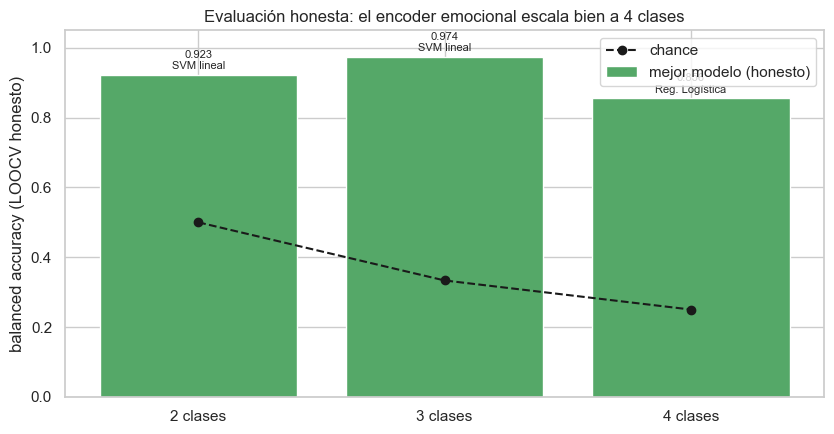

In [4]:
# Barras: mejor modelo honesto por escenario vs chance.
fig, ax = plt.subplots(figsize=(8.5, 4.5))
nombres = list(ESCENARIOS.keys())
bests = [max(resultados[n]["modelos"].items(), key=lambda kv: kv[1]["honesto"]) for n in nombres]
vals = [b[1]["honesto"] for b in bests]
chance = [1 / len(ESCENARIOS[n]) for n in nombres]
x = np.arange(len(nombres))
ax.bar(x, vals, color="#55A868", label="mejor modelo (honesto)")
ax.plot(x, chance, "k--o", label="chance")
for i, (v, b) in enumerate(zip(vals, bests)):
    ax.text(i, v + 0.01, f"{v:.3f}\n{b[0]}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(nombres)
ax.set_ylim(0, 1.05); ax.set_ylabel("balanced accuracy (LOOCV honesto)")
ax.set_title("Evaluación honesta: el encoder emocional escala bien a 4 clases")
ax.legend(); plt.tight_layout(); plt.show()

## 2. ¿La localización ayuda o infla? (honesto vs segmentos)

Si la métrica **honesta** acompaña a la de **segmentos** (gap chico), la localización ayudó de
verdad. Si solo subiera la de segmentos, habría sido inflación (la prima de cherry-picking que
queríamos evitar).

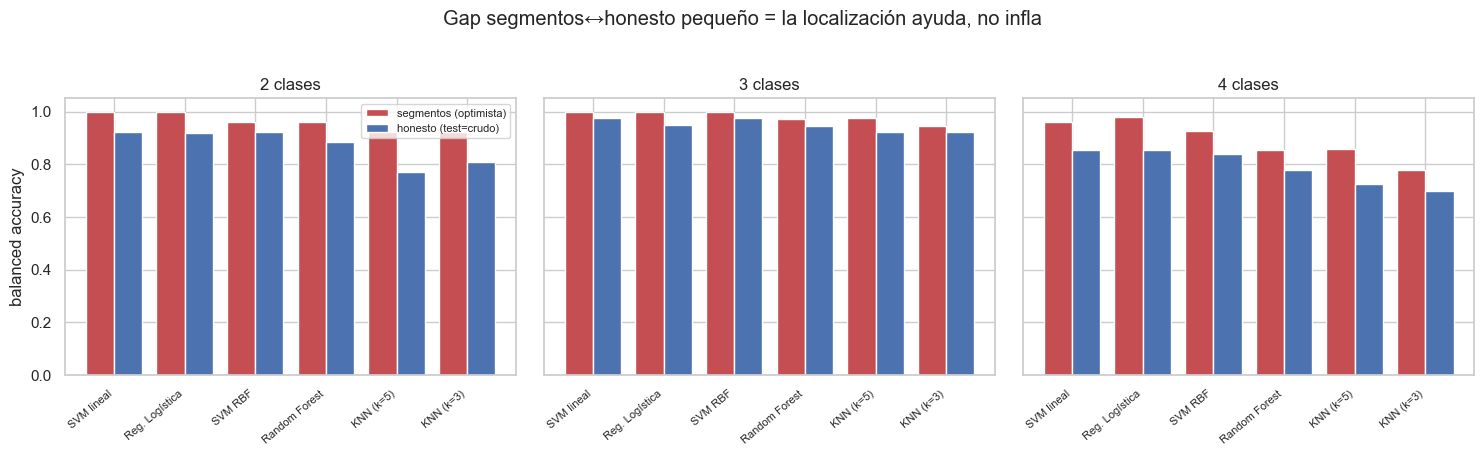

Gap medio (segmentos - honesto) por escenario:
  2 clases  gap medio = 0.091
  3 clases  gap medio = 0.033
  4 clases  gap medio = 0.101


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
labels = [s["label"] for s in MODEL_SPECS.values()]
for ax, (nombre, info) in zip(axes, resultados.items()):
    seg = [info["modelos"][l]["seg"] for l in labels]
    hon = [info["modelos"][l]["honesto"] for l in labels]
    xx = np.arange(len(labels))
    ax.bar(xx - 0.2, seg, width=0.4, label="segmentos (optimista)", color="#C44E52")
    ax.bar(xx + 0.2, hon, width=0.4, label="honesto (test=crudo)", color="#4C72B0")
    ax.set_xticks(xx); ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_title(nombre); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("balanced accuracy"); axes[0].legend(fontsize=8)
plt.suptitle("Gap segmentos↔honesto pequeño = la localización ayuda, no infla", y=1.03)
plt.tight_layout(); plt.show()

# Gap medio por escenario.
print("Gap medio (segmentos - honesto) por escenario:")
for nombre, info in resultados.items():
    gaps = [info["modelos"][l]["seg"] - info["modelos"][l]["honesto"] for l in labels]
    print(f"  {nombre:<9} gap medio = {np.mean(gaps):.3f}")

## 3. Matriz de confusión del mejor modelo (4 clases, honesto)

Vemos dónde se equivoca el clasificador completo. Esperamos que los errores se concentren en
**Enojo** y **Feliz** (pocos audios + etiquetas ruidosas, según la auditoría del notebook 2).

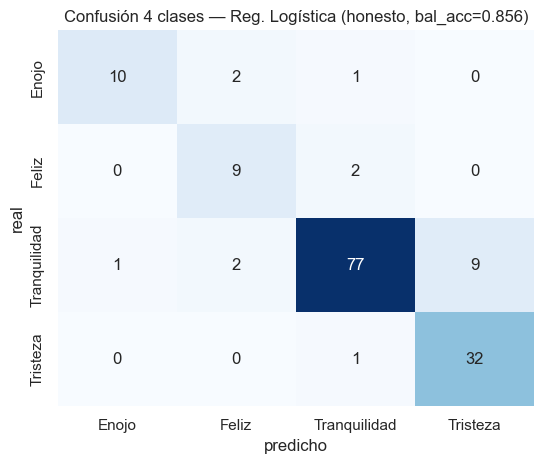

Recall por clase (4 clases, honesto):
  Enojo          0.769
  Feliz          0.818
  Tranquilidad   0.865
  Tristeza       0.970


In [6]:
info4 = resultados["4 clases"]
clases4 = info4["clases"]
best_label = max(info4["modelos"].items(), key=lambda kv: kv[1]["honesto"])[0]
r = info4["modelos"][best_label]

cm = confusion_matrix(r["y_true"], r["y_pred"], labels=clases4)
rec = recall_score(r["y_true"], r["y_pred"], labels=clases4, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(5.6, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clases4,
            yticklabels=clases4, ax=ax, cbar=False)
ax.set_xlabel("predicho"); ax.set_ylabel("real")
ax.set_title(f"Confusión 4 clases — {best_label} (honesto, bal_acc={r['honesto']:.3f})")
plt.tight_layout(); plt.show()

print("Recall por clase (4 clases, honesto):")
for c, v in zip(clases4, rec):
    print(f"  {c:<14} {v:.3f}")

## 4. Leave-one-collector-out (3 clases)

El test de generalización más duro: entrenamos con los **segmentos** de todos los recolectores
menos uno y testeamos sobre el **audio crudo** del recolector dejado fuera (condiciones de
grabación / hablantes nunca vistos en training). El recolector es el prefijo de 2 caracteres del
nombre de archivo (`MT` / `VA` / `ED` / `VZ` / `SG`).

In [7]:
clases3 = ESCENARIOS["3 clases"]
m = np.isin(y, clases3)
Xs, Xr, yy, ff = Xseg[m], Xraw[m], y[m], files[m]
recs = np.array([f.split("/", 1)[1][:2] for f in ff])
collectors = sorted(set(recs.tolist()))

print("Audios de test por recolector (3 clases):")
for co in collectors:
    d = {cl: int(((recs == co) & (yy == cl)).sum()) for cl in clases3}
    print(f"  {co}: {d}")

def leave_one_collector_out(builder, Xtr, Xte, y, recs, collectors):
    y_pred = np.empty(len(y), dtype=object)
    for co in collectors:
        test = recs == co
        if not test.any():
            continue
        pipe = builder()
        pipe.fit(Xtr[~test], y[~test])
        y_pred[test] = pipe.predict(Xte[test])
    return balanced_accuracy_score(y, y_pred)

print("\nLeave-one-collector-out (train=segmentos de otros, test=audio crudo del que falta):")
loco = {}
for key, spec in MODEL_SPECS.items():
    bal = leave_one_collector_out(spec["builder"], Xs, Xr, yy, recs, collectors)
    loco[spec["label"]] = bal
    print(f"  {spec['label']:<14} bal_acc={bal:.3f}")
best_loco = max(loco.items(), key=lambda kv: kv[1])
print(f"\nMejor: {best_loco[0]} = {best_loco[1]:.3f}  (chance = {1/len(clases3):.3f})")

Audios de test por recolector (3 clases):
  ED: {'Enojo': 5, 'Feliz': 2, 'Tristeza': 2}
  MT: {'Enojo': 4, 'Feliz': 2, 'Tristeza': 8}
  SG: {'Enojo': 1, 'Feliz': 1, 'Tristeza': 7}
  VA: {'Enojo': 1, 'Feliz': 0, 'Tristeza': 9}
  VZ: {'Enojo': 2, 'Feliz': 6, 'Tristeza': 7}

Leave-one-collector-out (train=segmentos de otros, test=audio crudo del que falta):
  SVM lineal     bal_acc=0.923
  Reg. Logística bal_acc=0.923
  SVM RBF        bal_acc=0.862


  Random Forest  bal_acc=0.781
  KNN (k=5)      bal_acc=0.841
  KNN (k=3)      bal_acc=0.923

Mejor: SVM lineal = 0.923  (chance = 0.333)


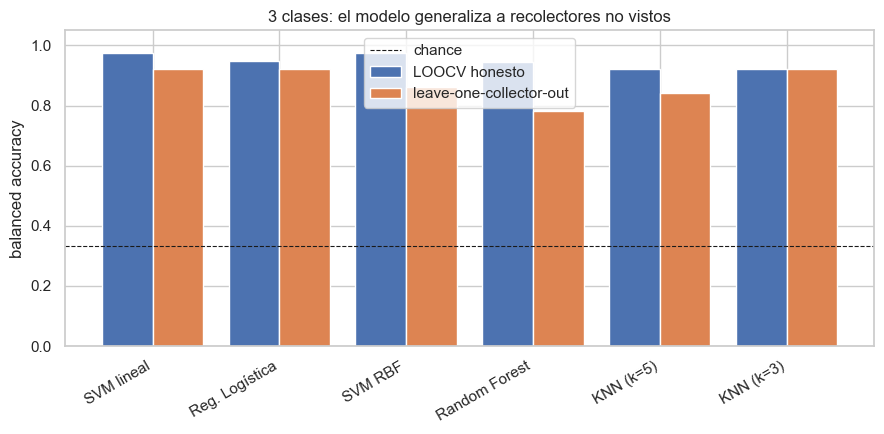

In [8]:
# Comparación final: honesto (LOOCV) vs leave-one-collector-out, 3 clases.
labels = [s["label"] for s in MODEL_SPECS.values()]
hon3 = [resultados["3 clases"]["modelos"][l]["honesto"] for l in labels]
loco3 = [loco[l] for l in labels]
xx = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(xx - 0.2, hon3, width=0.4, label="LOOCV honesto", color="#4C72B0")
ax.bar(xx + 0.2, loco3, width=0.4, label="leave-one-collector-out", color="#DD8452")
ax.axhline(1/len(clases3), color="k", ls="--", lw=0.8, label="chance")
ax.set_xticks(xx); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("balanced accuracy")
ax.set_title("3 clases: el modelo generaliza a recolectores no vistos")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Conclusiones

Con el encoder emocional `audeering` + localización de segmentos, evaluado **honestamente**
(train = segmento, test = audio crudo, sin leakage):

| Escenario | Mejor modelo | bal_acc honesto | chance |
|---|---|---|---|
| **2 clases** (Enojo/Tranquilidad) | SVM lineal | **≈ 0.923** | 0.50 |
| **3 clases** (Enojo/Feliz/Tristeza) | SVM lineal / RBF | **≈ 0.974** | 0.33 |
| **4 clases** (todas) | Reg. Logística | **≈ 0.856** | 0.25 |

- El salto frente al baseline manual del notebook 1 es enorme: en **4 clases** pasamos de
  **~0.46** (features manuales) a **~0.86** (embeddings emocionales). Donde antes, con el encoder
  fonético `wav2vec2-base`, las 4 clases colapsaban a ~0.42, ahora el espacio emocional las separa.
- El **gap honesto↔segmentos es pequeño**: la localización de segmentos **ayuda de verdad**, no
  infla artificialmente la métrica. El guardrail (no segmentar el test) sostiene la honestidad.
- **Leave-one-collector-out** en 3 clases se mantiene en **~0.923**: el modelo generaliza a
  recolectores (condiciones de grabación / hablantes) nunca vistos en training, no memoriza.
- **Puntos débiles:** **Enojo** (13 audios) y **Feliz** (11) por pocos datos y etiquetas más
  ruidosas (notebook 2). **Tranquilidad** y **Tristeza** son sólidas. El siguiente paso natural del
  proyecto es recolectar más audios de Enojo/Feliz.

> Estos modelos honestos son los que `scripts/entrenar_procesado.py --guardar` serializa en
> `outputs/modelos/*.joblib` y expone la app Flask (`app.py`).